# IS II Dataset Analysis, Combination, and Model Development

In [ ]:
# Load Neccessary Packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from itertools import combinations

# Dataset 1 - Campus Selection CSV

In [ ]:
df1 = pd.read_csv('Campus_Selection.csv')
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
dtypes: float64(5), int64(1), object(8)
memory usage: 23.6+ KB


In [ ]:
df1.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [ ]:
df1.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000


In [ ]:
df1.describe(include=['object'])

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
count,215,215,215,215,215,215,215,215
unique,2,2,2,3,3,2,2,2
top,M,Central,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
freq,139,116,131,113,145,141,120,148


In [1]:
df1.isnull().sum()

NameError: name 'df1' is not defined

# Dataset 2 - Research Information 3 CSV

In [ ]:
df2 = pd.read_csv('ResearchInformation3.csv')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Department   493 non-null    object 
 1   Gender       493 non-null    object 
 2   HSC          493 non-null    float64
 3   SSC          493 non-null    float64
 4   Income       493 non-null    object 
 5   Hometown     493 non-null    object 
 6   Computer     493 non-null    int64  
 7   Preparation  493 non-null    object 
 8   Gaming       493 non-null    object 
 9   Attendance   493 non-null    object 
 10  Job          493 non-null    object 
 11  English      493 non-null    int64  
 12  Extra        493 non-null    object 
 13  Semester     493 non-null    object 
 14  Last         493 non-null    float64
 15  Overall      493 non-null    float64
dtypes: float64(4), int64(2), object(10)
memory usage: 61.8+ KB


In [ ]:
df2.head()

,Department,Gender,HSC,SSC,Income,Hometown,Computer,Preparation,Gaming,Attendance,Job,English,Extra,Semester,Last,Overall
0,Business Administration,Male,4.17,4.84,"Low (Below 15,000)",Village,3,More than 3 Hours,0-1 Hour,80%-100%,No,3,Yes,6th,3.220,3.350
1,Business Administration,Female,4.92,5.00,"Upper middle (30,000-50,000)",City,3,0-1 Hour,0-1 Hour,80%-100%,No,3,Yes,7th,3.467,3.467
2,Business Administration,Male,5.00,4.83,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,More than 3 Hours,80%-100%,No,4,Yes,3rd,4.000,3.720
3,Business Administration,Male,4.00,4.50,"High (Above 50,000)",City,5,More than 3 Hours,More than 3 Hours,80%-100%,No,5,Yes,4th,3.800,3.750
4,Business Administration,Female,2.19,3.17,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,2-3 Hours,80%-100%,No,3,Yes,4th,3.940,3.940


In [ ]:
df2.describe()

,HSC,SSC,Computer,English,Last,Overall
count,493.000000,493.000000,493.000000,493.000000,493.000000,493.000000
mean,4.156775,4.767647,3.338742,3.569980,3.163888,3.188383
std,0.546504,0.349538,1.252988,0.870515,0.641475,0.591801
min,2.170000,3.000000,1.000000,1.000000,1.000000,1.000000
25%,3.830000,4.680000,3.000000,3.000000,2.810000,2.880000
50%,4.170000,4.940000,3.000000,4.000000,3.250000,3.270000
75%,4.500000,5.000000,4.000000,4.000000,3.670000,3.680000
max,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000


In [ ]:
df2.describe(include=['object'])

,Department,Gender,Income,Hometown,Preparation,Gaming,Attendance,Job,Extra,Semester
count,493,493,493,493,493,493,493,493,493,493
unique,10,2,10,2,3,3,4,2,2,11
top,Computer Science and Engineering,Male,"Lower middle (15,000-30,000)",Village,2-3 Hours,More than 3 Hours,60%-79%,No,No,2nd
freq,443,328,174,280,228,302,217,459,288,183


In [ ]:
df2.isnull().sum()

,0
Department,0
Gender,0
HSC,0
SSC,0
Income,0
Hometown,0
Computer,0
Preparation,0
Gaming,0
Attendance,0


In [ ]:
df2 = df2.drop(columns=['Unnamed: 0'])

#Dataset 3 - Data Academic Performance CSV

## Loading Dataset

In [ ]:
df3 = pd.read_csv('data_academic_performance.csv')
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   COD_S11           12411 non-null  object 
 1   GENDER            12411 non-null  object 
 2   EDU_FATHER        12411 non-null  object 
 3   EDU_MOTHER        12411 non-null  object 
 4   OCC_FATHER        12411 non-null  object 
 5   OCC_MOTHER        12411 non-null  object 
 6   STRATUM           12411 non-null  object 
 7   SISBEN            12411 non-null  object 
 8   PEOPLE_HOUSE      12411 non-null  object 
 9   Unnamed: 9        0 non-null      float64
 10  INTERNET          12411 non-null  object 
 11  TV                12411 non-null  object 
 12  COMPUTER          12411 non-null  object 
 13  WASHING_MCH       12411 non-null  object 
 14  MIC_OVEN          12411 non-null  object 
 15  CAR               12411 non-null  object 
 16  DVD               12411 non-null  object

In [ ]:
df3.head()

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


## Selecting Useful Columns

In [ ]:
useabledf3 = df3[['EDU_FATHER','EDU_MOTHER', 'OCC_FATHER', 'OCC_MOTHER', 'MAT_S11', 'ENG_S11', 'CR_S11', 'BIO_S11', 'CC_S11', 'ACADEMIC_PROGRAM', 'GENDER', 'SCHOOL_NAT']]

In [ ]:
useabledf3.head()

,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,MAT_S11,ENG_S11,CR_S11,BIO_S11,CC_S11,ACADEMIC_PROGRAM,GENDER,SCHOOL_NAT
0,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,71,82,81,86,61,INDUSTRIAL ENGINEERING,F,PRIVATE
1,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,83,88,75,100,66,INDUSTRIAL ENGINEERING,F,PRIVATE
2,Not sure,Not sure,Independent,Home,52,42,49,46,38,ELECTRONIC ENGINEERING,M,PRIVATE
3,Not sure,Not sure,Other occupation,Independent,56,73,55,64,51,INDUSTRIAL ENGINEERING,F,PRIVATE
4,Complete professional education,Complete professional education,Executive,Home,80,92,65,85,76,INDUSTRIAL ENGINEERING,M,PRIVATE


## Cleaning & Preprocessing

In [ ]:
useabledf3.isnull().sum()


,0
EDU_FATHER,0
EDU_MOTHER,0
OCC_FATHER,0
OCC_MOTHER,0
MAT_S11,0
ENG_S11,0
CR_S11,0
BIO_S11,0
CC_S11,0
ACADEMIC_PROGRAM,0


In [ ]:
useabledf3['EDU_FATHER'].unique()

array(['Incomplete Professional Education', 'Complete Secundary',
       'Not sure', 'Complete professional education',
       'Incomplete Secundary', 'Incomplete technical or technological',
       'Complete technique or technology', 'Incomplete primary ',
       'Complete primary ', 'Postgraduate education', '0', 'Ninguno'],
      dtype=object)

In [ ]:
useabledf3['EDU_MOTHER'].unique()

array(['Complete technique or technology',
       'Complete professional education', 'Not sure',
       'Complete Secundary', 'Incomplete technical or technological',
       'Incomplete primary ', 'Incomplete Secundary',
       'Incomplete Professional Education', 'Postgraduate education',
       'Complete primary ', '0', 'Ninguno'], dtype=object)

In [ ]:
useabledf3['OCC_FATHER'].unique()

array(['Technical or professional level employee', 'Entrepreneur ',
       'Independent', 'Other occupation', 'Executive',
       'Small entrepreneur ', 'Independent professional', 'Operator', '0',
       'Retired', 'Auxiliary or Administrative', 'Home'], dtype=object)

In [ ]:
useabledf3['OCC_MOTHER'].unique()

array(['Home', 'Independent professional', 'Independent', 'Executive',
       'Operator', 'Entrepreneur ', 'Small entrepreneur ',
       'Technical or professional level employee', '0',
       'Auxiliary or Administrative', 'Other occupation', 'Retired'],
      dtype=object)

In [ ]:
useabledf3['GENDER'].unique()

array(['F', 'M'], dtype=object)

In [ ]:
useabledf3['EDU_FATHER'] = useabledf3['EDU_FATHER'].replace(['Ninguno', '0'], 'None')
useabledf3['EDU_MOTHER'] = useabledf3['EDU_MOTHER'].replace(['Ninguno', '0'], 'None')

/tmp/ipython-input-1288879636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useabledf3['EDU_FATHER'] = useabledf3['EDU_FATHER'].replace(['Ninguno', '0'], 'None')
/tmp/ipython-input-1288879636.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useabledf3['EDU_MOTHER'] = useabledf3['EDU_MOTHER'].replace(['Ninguno', '0'], 'None')


In [ ]:
# Creates a new DataFrame for the encoded data
df3_encoded = useabledf3.copy()

occupation_map = {
    'Executive': 6,
    'Technical or professional level employee': 5,
    'Independent professional': 5,
    'Independent': 5,
    'Entrepreneur ': 4,
    'Small entrepreneur ': 3,
    'Auxiliary or Administrative': 3,
    'Operator': 2,
    'Other occupation': 1,
    'Home': 0,
    'Retired': 0,
    '0': -1
}

edu_order = [
    'None',
    'Not sure',
    'Incomplete primary ',
    'Complete primary ',
    'Incomplete Secundary',
    'Complete Secundary',
    'Incomplete technical or technological',
    'Complete technique or technology',
    'Incomplete Professional Education',
    'Complete professional education',
    'Postgraduate education'
]

# Encoding CATEGORICAL COLUMNS
df3_encoded['GENDER'] = OrdinalEncoder(categories=[['M', 'F']]).fit_transform(df3_encoded[['GENDER']])
df3_encoded['EDU_FATHER'] = OrdinalEncoder(categories=[edu_order]).fit_transform(df3_encoded[['EDU_FATHER']])
df3_encoded['EDU_MOTHER'] = OrdinalEncoder(categories=[edu_order]).fit_transform(df3_encoded[['EDU_MOTHER']])
df3_encoded['OCC_FATHER'] =df3_encoded['OCC_FATHER'].map(occupation_map)
df3_encoded['OCC_MOTHER'] = df3_encoded['OCC_MOTHER'].map(occupation_map)
df3_encoded['SCHOOL_NAT'] = OrdinalEncoder(categories=[['PUBLIC', 'PRIVATE']]).fit_transform(df3_encoded[['SCHOOL_NAT']])

In [ ]:
df3_encoded.isnull().sum()

,0
EDU_FATHER,0
EDU_MOTHER,0
OCC_FATHER,0
OCC_MOTHER,0
MAT_S11,0
ENG_S11,0
CR_S11,0
BIO_S11,0
CC_S11,0
ACADEMIC_PROGRAM,0


## EDA

In [ ]:
df3_encoded.describe()

,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,MAT_S11,ENG_S11,CR_S11,BIO_S11,CC_S11,GENDER,SCHOOL_NAT
count,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000
mean,5.990009,6.218838,3.455644,2.376360,64.320764,61.801064,60.778422,63.950528,60.705181,0.406333,0.528966
std,2.873351,2.669879,2.133617,2.349294,11.873650,14.297777,10.025876,11.156869,10.120524,0.491168,0.499180
min,0.000000,0.000000,-1.000000,-1.000000,26.000000,26.000000,24.000000,11.000000,0.000000,0.000000,0.000000
25%,4.000000,5.000000,2.000000,0.000000,56.000000,50.000000,54.000000,56.000000,54.000000,0.000000,0.000000
50%,5.000000,6.000000,5.000000,2.000000,64.000000,59.000000,61.000000,64.000000,60.000000,0.000000,1.000000
75%,9.000000,9.000000,5.000000,5.000000,72.000000,72.000000,67.000000,71.000000,67.000000,1.000000,1.000000
max,10.000000,10.000000,6.000000,6.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000,1.000000


In [ ]:
df3_encoded['ACADEMIC_PROGRAM'].value_counts()

,count
ACADEMIC_PROGRAM,
INDUSTRIAL ENGINEERING,5318
CIVIL ENGINEERING,3320
MECHANICAL ENGINEERING,1135
CHEMICAL ENGINEERING,1000
ELECTRONIC ENGINEERING,849
ELECTRIC ENGINEERING,278
MECHATRONICS ENGINEERING,82
CATASTRAL ENGINEERING AND GEODESY,78
PRODUCTION ENGINEERING,60


## Training Models

In [ ]:
X = df3_encoded.drop(columns=['ACADEMIC_PROGRAM'])
Y = df3_encoded['ACADEMIC_PROGRAM']

X_train, X_test, y_train, y_test  = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

### KNN

In [ ]:
# Function to determin the optimal features to determine a target and the optimal K for that combination of features
def find_optimal_features_and_k(X, y, max_features=None, k_range=range(2, 21)):
    results = []
    if max_features is None:
        max_features = X.shape[1]

    best_score = 0
    best_features = None
    best_k = None

    # Loop through different numbers of features
    for num_features in range(1, max_features + 1):
        # Select top num_features using SelectKBest
        selector = SelectKBest(score_func=f_classif, k=num_features)
        X_new = selector.fit_transform(X, y)
        selected_features = selector.get_support(indices=True)

        # Loop through k values
        for k in k_range:
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_new, y)
            score = knn.score(X_new, y)

            # Update best parameters if better score is found
            if score > best_score:
                best_score = score
                best_features = selected_features
                best_k = k

            # Append results
            results.append({
                'features': str(selected_features),
                'k': k,
                'accuracy': score
            })

    print("optimal_num_features: " + str(len(best_features)) + "\nselected_features: " + str(best_features) + "\noptimal_k: " + str(best_k) + "\nbest_accuracy: " + str(best_score))

    return pd.DataFrame(results)


In [ ]:
results_df = find_optimal_features_and_k(scaled_X_train, y_train)

optimal_num_features: 9
selected_features: [ 0  1  4  5  6  7  8  9 10]
optimal_k: 2
best_accuracy: 0.6590451248992748


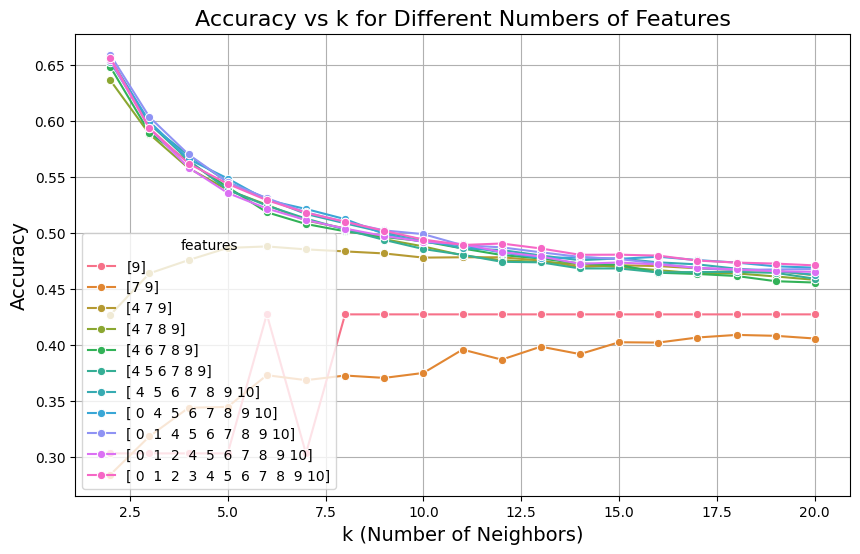

In [ ]:
# Plot accuracies
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x='k', y='accuracy', hue='features', marker='o')

# Add titles and labels
plt.title('Accuracy vs k for Different Numbers of Features', fontsize=16)
plt.xlabel('k (Number of Neighbors)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(True)
plt.show()

In [ ]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)
score = knn.score(X_train, y_train)
print("accuracy: " + str(score))

### XGBoost

### Random Forest

# Dataset 4 - HS School Data SCV

## Loading and Cleaning

In [ ]:
# Load Data Set
df4 = pd.read_csv('HS_SCHOOL_DATA.csv')
df4.info()

/tmp/ipython-input-1117597805.py:2: DtypeWarning: Columns (38,39,40,41,62,66,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df4 = pd.read_csv('HS_SCHOOL_DATA.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943010 entries, 0 to 943009
Data columns (total 68 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     943010 non-null  int64  
 1   CR.HS          943010 non-null  float64
 2   MATH.HS        943010 non-null  float64
 3   NS.HS          943010 non-null  float64
 4   SC.HS          922017 non-null  float64
 5   ENG.HS         943010 non-null  float64
 6   QR.PRO         943010 non-null  float64
 7   CR.PRO         943010 non-null  float64
 8   CS.PRO         943010 non-null  float64
 9   ENG.PRO        943010 non-null  float64
 10  WC.PRO         943010 non-null  float64
 11  EA.PRO         15025 non-null   float64
 12  HA.PRO         70051 non-null   float64
 13  AD.PRO         27251 non-null   float64
 14  IPD.PRO        6203 non-null    float64
 15  DCS.PRO        12408 non-null   float64
 16  MSD.PRO        11636 non-null   float64
 17  DPLS.PRO       42006 non-null

In [ ]:
df4.head()

,Unnamed: 0,CR.HS,MATH.HS,NS.HS,SC.HS,ENG.HS,QR.PRO,CR.PRO,CS.PRO,ENG.PRO,...,degree.method,degree.focus,inst_funding,code,int.u,comp.u,wasm.u,car.u,fems,fefs
0,1,57.32,58.13,51.92,55.90,54.57,12.2,12.2,11.1,12.8,...,on-campus,ECONOMY,on-campus,SABER1120072031620,NaN,NaN,NaN,NaN,NaN,NaN
1,2,51.21,36.38,43.37,52.23,45.98,9.3,9.9,10.1,10.3,...,on-campus,MANAGEMENT,on-campus,SABER1120072214474,NaN,NaN,NaN,NaN,NaN,NaN
2,3,45.01,44.48,40.94,43.06,35.21,10.5,9.4,9.8,9.7,...,on-line,MANAGEMENT,on-line,SABER1120072297325,NaN,NaN,NaN,NaN,NaN,NaN
3,4,42.76,40.82,43.37,46.81,36.71,9.3,9.4,10.2,9.4,...,on-campus,PSYCHOLOGY,on-campus,SABER1120072044755,NaN,NaN,NaN,NaN,NaN,NaN
4,5,49.19,40.82,49.87,54.05,48.43,9.5,9.9,9.9,10.5,...,on-campus,MANAGEMENT,on-campus,SABER1120072233217,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
numeric_columns = ['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS',]
useabledf4 = df4[['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS', 'degree', 'degree.focus', 'gender', 'fefu', 'femu', 'fofu', 'fomu']]

for i in numeric_columns:
#  useabledf4.drop(useabledf4[(useabledf4[i] < 0) | (useabledf4[i] > 100)].index, inplace=True)
  useabledf4[i] = useabledf4[i].clip(lower=0, upper=100)
useabledf4.info()

/tmp/ipython-input-741301231.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useabledf4[i] = useabledf4[i].clip(lower=0, upper=100)
/tmp/ipython-input-741301231.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useabledf4[i] = useabledf4[i].clip(lower=0, upper=100)
/tmp/ipython-input-741301231.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943010 entries, 0 to 943009
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ENG.HS        943010 non-null  float64
 1   SC.HS         922017 non-null  float64
 2   MATH.HS       943010 non-null  float64
 3   CR.HS         943010 non-null  float64
 4   degree        943010 non-null  object 
 5   degree.focus  943010 non-null  object 
 6   gender        941997 non-null  object 
 7   fefu          116538 non-null  object 
 8   femu          118593 non-null  object 
 9   fofu          108689 non-null  object 
 10  fomu          108689 non-null  object 
dtypes: float64(4), object(7)
memory usage: 79.1+ MB


In [ ]:
useabledf4.isnull().sum()

,0
ENG.HS,0
SC.HS,20993
MATH.HS,0
CR.HS,0
degree,0
degree.focus,0
gender,1013
fefu,826472
femu,824417
fofu,834321


In [ ]:
# Replace Numeric nulls with 0
useabledf4.fillna({'SC.HS' : 0}, inplace= True)

useabledf4.fillna({'fefu' : 'Does not know'}, inplace= True)
useabledf4.fillna({'femu' : 'Does not know'}, inplace= True)
useabledf4.fillna({'fofu' : 'Unknown'}, inplace= True)
useabledf4.fillna({'fomu' : 'Unknown'}, inplace= True)
useabledf4.fillna({'gender' : 'Unknown'}, inplace= True)

/tmp/ipython-input-11033937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useabledf4.fillna({'SC.HS' : 0}, inplace= True)
/tmp/ipython-input-11033937.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useabledf4.fillna({'fefu' : 'Does not know'}, inplace= True)
/tmp/ipython-input-11033937.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useabledf4.fillna({'femu' : 'Does not know'}, inplace= True)
/tmp/ipython-input-11033937.p

In [ ]:
useabledf4.isnull().sum()

,0
ENG.HS,0
SC.HS,0
MATH.HS,0
CR.HS,0
degree,0
degree.focus,0
gender,0
fefu,0
femu,0
fofu,0


## EDA

In [ ]:
useabledf4.describe()

,ENG.HS,SC.HS,MATH.HS,CR.HS
count,100488.000000,100488.000000,100488.000000,100488.000000
mean,50.828028,48.689357,49.823391,51.145203
std,12.206718,8.427964,10.642345,6.945445
min,0.000000,0.000000,0.000000,0.000000
25%,42.200000,43.060000,44.480000,47.140000
50%,48.430000,48.620000,49.620000,51.210000
75%,56.320000,54.050000,55.710000,55.250000
max,100.000000,94.220000,100.000000,99.690000


In [ ]:
useabledf4.describe(include=['object'])

,degree,degree.focus,gender,fefu,femu,fofu,fomu
count,100487,100487,100488,100488,100488,100488,100488
unique,378,55,3,10,10,22,22
top,BUSINESS ADMINISTRATION,MANAGEMENT,F,complete secondary school,complete secondary school,Self-employed,Stay-at-home dad
freq,8804,15017,58048,22386,24572,23230,32892


## PreProcessing

In [ ]:
useabledf4['fofu'].unique()

array(['Independent professional', 'worker employee and operator',
       'Stay-at-home dad', 'Little Businessman', 'executive director',
       'Self-employed', 'Other activity or occupation',
       'Technical or professional level employee', 'Pensionado',
       'general manager', 'businessman', 'auxiliary level employee',
       'unemployed', 'does not apply', 'worker or government employee',
       'Worker or employee of a private company', 'employer',
       'Domestic employee', 'day laborer', 'Unpaid family worker',
       'Trabajador sin remuneración en empresas o negocios de otros hogares',
       'Unknown'], dtype=object)

In [ ]:
useabledf4['fefu'].unique()

array(['incomplete primary school', 'complete Technical degree',
       'complete professional education', 'primary school complete',
       'incomplete secondary school', 'Incomplete professional education',
       'complete secondary school', 'Postgraduate',
       'incomplete technical degree', 'Does not know'], dtype=object)

In [ ]:
useabledf4['gender'].unique()

array(['M', 'F', 'Unknown'], dtype=object)

In [ ]:
# Creates a new DataFrame for the encoded data
df4_encoded = useabledf4.copy()

# Ordinal Encode fefu, femu, fofu, fomu
df4_encoded['gender'] = OrdinalEncoder(categories=[['M', 'Unknown', 'F']]).fit_transform(useabledf4[['gender']])

df4_encoded['fefu'] = OrdinalEncoder(categories=[[
    'incomplete primary school', 'complete Technical degree',
    'complete professional education', 'primary school complete',
    'incomplete secondary school', 'Incomplete professional education',
    'complete secondary school', 'Postgraduate',
    'incomplete technical degree', 'Does not know', 'does not apply'
    ]]).fit_transform(useabledf4[['fefu']])
df4_encoded['femu'] = OrdinalEncoder(categories=[[
    'incomplete primary school', 'complete Technical degree',
    'complete professional education', 'primary school complete',
    'incomplete secondary school', 'Incomplete professional education',
    'complete secondary school', 'Postgraduate',
    'incomplete technical degree', 'Does not know', 'does not apply'
    ]]).fit_transform(useabledf4[['femu']])


df4_encoded['fofu'] = OrdinalEncoder(categories=[[
    'Independent professional', 'worker employee and operator',
    'Stay-at-home dad', 'Little Businessman', 'executive director',
    'Self-employed', 'Other activity or occupation',
    'Technical or professional level employee', 'Pensionado',
    'general manager', 'businessman', 'auxiliary level employee',
    'unemployed', 'does not apply', 'worker or government employee',
    'Worker or employee of a private company', 'employer',
    'Domestic employee', 'day laborer', 'Unpaid family worker',
    'Trabajador sin remuneración en empresas o negocios de otros hogares', 'Unknown'
    ]]).fit_transform(useabledf4[['fofu']])
df4_encoded['fomu'] = OrdinalEncoder(categories=[[
    'Independent professional', 'worker employee and operator',
    'Stay-at-home dad', 'Little Businessman', 'executive director',
    'Self-employed', 'Other activity or occupation',
    'Technical or professional level employee', 'Pensionado',
    'general manager', 'businessman', 'auxiliary level employee',
    'unemployed', 'does not apply', 'worker or government employee',
    'Worker or employee of a private company', 'employer',
    'Domestic employee', 'day laborer', 'Unpaid family worker', 'Worker without remuneration',
    'Trabajador sin remuneración en empresas o negocios de otros hogares', 'Unknown'
    ]]).fit_transform(useabledf4[['fomu']])

## Train Models

In [ ]:
# Set degree as Target
Y = df4_encoded['degree']
# List of potential suitable features
X = df4_encoded[['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS', 'gender', 'fefu', 'femu', 'fofu', 'fomu']]

In [ ]:
k = 5
# For general regression or balanced classification
# kf = KFold(n_splits=k, shuffle=True, random_state=42)
# For classification with imbalanced classes, specify the target variable
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Iterate through the folds
# for fold_idx, (train_index, test_index) in enumerate(skf.split(df4_encoded)): # or skf.split(df, df['target_column']) for stratified
for fold_idx, (train_index, test_index) in enumerate(skf.split(X, Y)):
    train_df = X.iloc[train_index]
    test_df = Y.iloc[test_index]

    print(f"Fold {fold_idx + 1}: Training samples = {len(train_df)}, Testing samples = {len(test_df)}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: Training samples = 754408, Testing samples = 188602
Fold 2: Training samples = 754408, Testing samples = 188602
Fold 3: Training samples = 754408, Testing samples = 188602
Fold 4: Training samples = 754408, Testing samples = 188602
Fold 5: Training samples = 754408, Testing samples = 188602


### Random Forest

In [ ]:
score = cross_val_score(RandomForestClassifier(n_estimators=500, random_state=42), X, Y, cv= skf, scoring="accuracy")
print(f'Scores for each fold are: {score}')
print(f'Average score: {"{:.2f}".format(score.mean())}')

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


### KNN

In [ ]:
# Function to determin the optimal features to determine a target and the optimal K for that combination of features
def find_optimal_features_and_k(X, y, max_features=None, k_range=range(5, 21)):
    results = []

    best_score = 0
    best_k = None
    # Loop through k values
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y)
        score = knn.score(X, y)

        # Update best parameters if better score is found
        if score > best_score:
            best_score = score
            best_k = k

        # Append results
        results.append({
            'k': k,
            'accuracy': score
        })

    print("optimal_k: " + str(best_k) + "\nbest_accuracy: " + str(best_score))

    return pd.DataFrame(results)


In [ ]:
results_df = find_optimal_features_and_k(X_train, y_train)

optimal_k: 5
best_accuracy: 0.27213788825145013


In [ ]:
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train, y_train)
score = knn.score(X_train, y_train)
print("accuracy: " + str(score))

accuracy: 0.17429162999331926


### XGB

#Combine Datasets